# Data Basic Processing

Import lab and define functions

In [ ]:
from statsmodels.tsa.statespace.dynamic_factor_mq import DynamicFactorMQ
import matplotlib.pyplot as plt
import statsmodels.api as sm
from pathlib import Path
import pandas as pd
import numpy as np
import glob
import os

# Get all CSV files in the folder
def combine_csv_files(folder_path):
    files = glob.glob(os.path.join(folder_path, "*.csv"))
    df_list = []
    for file in files:
        df = pd.read_csv(file)
        #datetime
        df["observation_date"] = pd.to_datetime(df["observation_date"])
        # date set index
        df = df.set_index("observation_date")
        df_list.append(df)
    
    data = pd.concat(df_list, axis=1)
    data = data.sort_index()
    return data

# Save the DataFrame to a CSV file if it does not already exist
def save_if_not_exists(df, filename):
    file = Path(filename)
    if not file.exists():
        df.to_csv(file)

# data preprocessing
def prepare_quarterly_gdp(data):
    # Calculate GDP growth rate
    ##Time series of real GDP
    gdp = data["GDPC1"].dropna().copy() 
    gdp.index = pd.to_datetime(gdp.index)
    gdp_q = gdp.asfreq("QS")
    # Calculate the quarter-on-quarter growth rate
    y_ar = 400 * np.log(gdp_q).diff()
    return y_ar.dropna()

# Prepare monthly explanatory variables for DFM
def prepare_monthly_explanatory(data):
    x_RAW = data.copy()
    x_RAW.index = pd.to_datetime(x_RAW.index)
    # Select monthly explanatory variables (exclude quarterly GDP target)
    monthly_vars = [
        "INDPRO", "PAYEMS", "HOUST", "RSXFS", "CPIAUCSL",
        "UNRATE", "FEDFUNDS", "GS10", "BAA10YM", "T10Y2Y"
    ]
    x_RAW = x_RAW[[col for col in monthly_vars if col in x_RAW.columns]].copy()
    # log-difference
    log_diff_vars = ["INDPRO", "PAYEMS", "HOUST", "RSXFS", "CPIAUCSL"]
    for col in log_diff_vars:
        if col in x_RAW.columns:
            x_RAW[col] = 100 * np.log(x_RAW[col]).diff()
    x = (x_RAW - x_RAW.mean()) / x_RAW.std()
    return x

def prepare_dfm_data(data):
    gdp = data["GDPC1"].dropna().copy() 
    gdp.index = pd.to_datetime(gdp.index)
    gdp_q = gdp.asfreq("QS")
    # Calculate the quarter-on-quarter growth rate
    gdp_growth_q = 400 * np.log(gdp_q).diff().dropna()
    # MOVE quarterly GDP growth to the end of the quarter and then to the start of the month
    # FOR EXAMPLE: 1990.1.1 (Q1) -> 1990.3.31 (end of Q1) -> 1990.3.1 
    gdp_growth_q.index = gdp_growth_q.index.to_period("Q").to_timestamp("M",how="end")
    gdp_growth_q.index = gdp_growth_q.index.to_period("M").to_timestamp(how="start")
    
    gdp_m = gdp_growth_q.resample("MS").asfreq()
    gdp_m.columns = ["gdp_q"]

    # Prepare monthly explanatory variables
    x_m = prepare_monthly_explanatory(data)
    #Merge mixed-frequency
    df_mixed = pd.concat([gdp_m, x_m], axis=1)

    return df_mixed

def run_ar1(y_ar):
    # Prepare the data for AR(1) model
    X_ar = sm.add_constant(y_ar.shift(1).dropna())
    y_ar = y_ar.loc[X_ar.index]
    #Fit the AR(1) model
    model_ar1 = sm.OLS(y_ar, X_ar).fit()
    return model_ar1

def run_dfm(df_mixed, n_factors=1, factor_order=1):
    model_dfm = DynamicFactorMQ(
        df_mixed,
        factors=n_factors,
        factor_orders=factor_order
    )
    result_dfm = model_dfm.fit(disp=False)
    return result_dfm

def nowcast_one_target(dfm_data, target_date, gdp_col="GDPC1", n_factors=2, factor_order=2):
    target_date = pd.Timestamp(target_date)

    # Use information available before target month
    train_data = dfm_data.loc[dfm_data.index < target_date].copy()
    res = run_dfm(train_data, n_factors=n_factors, factor_order=factor_order)

    # Number of months ahead from train end to target for example: if train ends at 2025-12-01 and target is 2026-03-01, steps = 4
    steps = (target_date.to_period("M") - train_data.index.max().to_period("M")).n
    fcst = res.forecast(steps=steps)
    # Extract target GDP nowcast
    nowcast_value = fcst.loc[target_date, gdp_col]

    return nowcast_value, fcst, res

Loading the data

In [ ]:
# use your own data folder path inside here ""
folder_path = r""
data = combine_csv_files(folder_path)
save_if_not_exists(data, "Combined_data.csv")
print(data.head())
print(data.columns)

                  BAA10YM  CPIAUCSL  FEDFUNDS      GDPC1  GS10   HOUST  \
observation_date                                                         
1990-01-01           1.73     127.5      8.23  10047.386  8.21  1551.0   
1990-02-01           1.67     128.0      8.24        NaN  8.47  1437.0   
1990-03-01           1.62     128.6      8.28        NaN  8.59  1289.0   
1990-04-01           1.51     128.9      8.26  10083.855  8.79  1248.0   
1990-05-01           1.65     129.1      8.18        NaN  8.76  1212.0   

                   INDPRO    PAYEMS  RSXFS  T10Y2Y  UNRATE  
observation_date                                            
1990-01-01        61.7290  109196.0    NaN    0.12     5.4  
1990-02-01        62.2896  109436.0    NaN    0.10     5.3  
1990-03-01        62.5999  109640.0    NaN   -0.04     5.2  
1990-04-01        62.4359  109674.0    NaN    0.06     5.4  
1990-05-01        62.6258  109828.0    NaN    0.12     5.4  
Index(['BAA10YM', 'CPIAUCSL', 'FEDFUNDS', 'GDPC1', 'GS

# Model Building

AR(1) Benchmark Model

In [3]:
# Prepare the quarterly GDP growth rate and run AR(1) model
data_ar = prepare_quarterly_gdp(data)
save_if_not_exists(data_ar, "Quarterly_GDP_Growth.csv")
#run AR(1) model
model_ar1 = run_ar1(data_ar)
print(model_ar1.summary())

                            OLS Regression Results                            
Dep. Variable:                  GDPC1   R-squared:                       0.018
Model:                            OLS   Adj. R-squared:                  0.010
Method:                 Least Squares   F-statistic:                     2.483
Date:                Mon, 23 Feb 2026   Prob (F-statistic):              0.117
Time:                        23:43:15   Log-Likelihood:                -409.26
No. Observations:                 141   AIC:                             822.5
Df Residuals:                     139   BIC:                             828.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.7869      0.427      6.532      0.0

Summary:
The model is GDP_t​=α+ϕGDP_t−1​+ε_t​,  
The AR(1) benchmark exhibits very low explanatory power,   
suggesting limited predictability from own lag.

DFM | Using State-space model + Kalman filter

In [12]:
# Prepare for DFM model
dfm_data = prepare_dfm_data(data)
save_if_not_exists(dfm_data, "DFM_data.csv")

In [34]:
# Model selection for DFM
res_11 = run_dfm(dfm_data, n_factors=1, factor_order=1)
res_12 = run_dfm(dfm_data, n_factors=1, factor_order=2)
res_13 = run_dfm(dfm_data, n_factors=1, factor_order=3)
res_21 = run_dfm(dfm_data, n_factors=2, factor_order=1)
res_22 = run_dfm(dfm_data, n_factors=2, factor_order=2)
res_23 = run_dfm(dfm_data, n_factors=3, factor_order=3)
spec_table = pd.DataFrame([
    {"model": "DFM(1,1)", "aic": res_11.aic, "bic": res_11.bic, "hqic": res_11.hqic, "llf": res_11.llf},
    {"model": "DFM(1,2)", "aic": res_12.aic, "bic": res_12.bic, "hqic": res_12.hqic, "llf": res_12.llf},
    {"model": "DFM(1,3)", "aic": res_13.aic, "bic": res_13.bic, "hqic": res_13.hqic, "llf": res_13.llf},
    {"model": "DFM(2,1)", "aic": res_21.aic, "bic": res_21.bic, "hqic": res_21.hqic, "llf": res_21.llf},
    {"model": "DFM(2,2)", "aic": res_22.aic, "bic": res_22.bic, "hqic": res_22.hqic, "llf": res_22.llf},
    {"model": "DFM(2,3)", "aic": res_23.aic, "bic": res_23.bic, "hqic": res_23.hqic, "llf": res_23.llf},
],)
print(spec_table.sort_values("bic"))

      model          aic          bic         hqic          llf
4  DFM(2,2)  4126.564918  4330.217145  4206.950923 -2013.282459
1  DFM(1,2)  4250.424460  4397.054064  4308.302384 -2089.212230
2  DFM(1,3)  4251.417968  4402.120616  4310.903612 -2088.708984
5  DFM(2,3)  4149.835900  4422.729884  4257.553147 -2007.917950
3  DFM(2,1)  4371.360583  4566.866721  4448.531148 -2137.680291
0  DFM(1,1)  4426.462707  4569.019266  4482.732910 -2178.231353


In [29]:
# Fit DFM model (Kalman filter)
dfm_result = run_dfm(dfm_data, n_factors=2, factor_order=2)
print(dfm_result.summary())
with open("dfm_summary.txt", "w", encoding="utf-8") as f:
    f.write(dfm_result.summary().as_text())

                               Dynamic Factor Results                              
Dep. Variable:        "GDPC1", and 10 more   No. Observations:                  434
Model:                Dynamic Factor Model   Log Likelihood               -2013.282
                   + 2 factors in 2 blocks   AIC                           4126.565
                     + AR(1) idiosyncratic   BIC                           4330.217
Date:                     Tue, 24 Feb 2026   HQIC                          4206.951
Time:                             22:24:39   EM Iterations                      218
Sample:                         01-01-1990                                         
                              - 02-01-2026                                         
Covariance Type:              Not computed                                         
                          Observation equation:                           
Factor loadings:          0          1    idiosyncratic: AR(1)        var.
----------

Factor Loading's summary:  
From the perspective of factor loadings, the two common factors exhibit a distinct economic division of labor: the first factor primarily loads on financial variables such as interest rates and credit spreads, and can be interpreted as a policy/monetary financial environment factor; the second factor mainly loads on monthly real economy indicators including industrial production, employment, retail sales, and housing starts, and can be interpreted as a real economic activity factor.


Smoothed factors

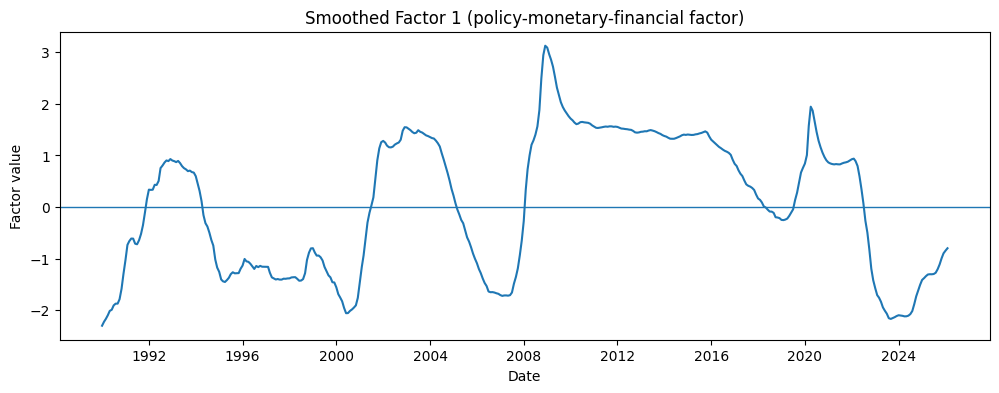

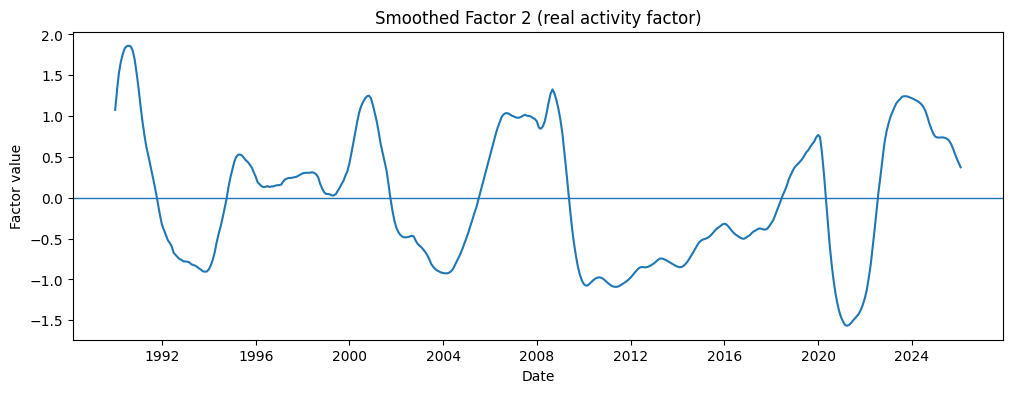

In [33]:
#Extract smoothed factors
factors_smoothed = dfm_result.factors.smoothed.copy()
#factor 1
plt.figure(figsize=(12, 4))
plt.plot(factors_smoothed.iloc[:, 0])
plt.title("Smoothed Factor 1 (policy-monetary-financial factor)")
plt.xlabel("Date")
plt.ylabel("Factor value")
plt.axhline(0, linewidth=1)
plt.show()
#factor 2
plt.figure(figsize=(12, 4))
plt.plot(factors_smoothed.iloc[:, 1])
plt.title("Smoothed Factor 2 (real activity factor)")
plt.xlabel("Date")
plt.ylabel("Factor value")
plt.axhline(0, linewidth=1)
plt.show()

Smoothed Factor Summary:  The chart illustrates the temporal evolution of two smoothed common factors. Factor 1 (Policy-Monetary-Financial Factor) primarily reflects the co-movement of financial conditions—such as interest rates and credit spreads—and the policy environment. Factor 2 (Real Economic Activity Factor) mainly captures the synchronized changes in real indicators including production, employment, and consumption.  
For instance, around the 2008–2009 financial crisis, Factor 1 exhibits pronounced volatility (a significant upward surge), indicating the model captured the dramatic shifts in financial conditions and the macroeconomic policy environment. Near the 2020 pandemic shock, Factor 2 rapidly declined before rebounding, reflecting the sharp contraction and subsequent recovery of real economic activity. The fluctuations in these factors indicate the intensity of changes in underlying macroeconomic conditions, rather than the magnitude of direct causal effects on GDP.


# Nowcasting

2025-Q4 Nowcasting

In [40]:
# 2025Q4 nowcast (target month label = 2025-12-01)
nowcast_2025q4, fcst_q4, res_q4 = nowcast_one_target(dfm_data, "2025-12-01", gdp_col="GDPC1")
print("2025Q4 GDP nowcast (qoq annualized %):", nowcast_2025q4)


2025Q4 GDP nowcast (qoq annualized %): 2.964215682557013


In [38]:

# 2026Q1 nowcast (target month label = 2026-03-01)
nowcast_2026q1, fcst_q1, res_q1 = nowcast_one_target(dfm_data, "2026-03-01", gdp_col="GDPC1")
print("2026Q1 GDP nowcast (qoq annualized %):", nowcast_2026q1)

2026Q1 GDP nowcast (qoq annualized %): 3.034434656076092


In [42]:
nowcast_summary = pd.DataFrame([
    {
        "model": "DFM(2,2)",
        "target_quarter": "2025Q4",
        "target_month_label": "2025-12-01",
        "nowcast_value": nowcast_2025q4,
        "unit": "qoq annualized %"
    },
    {
        "model": "DFM(2,2)",
        "target_quarter": "2026Q1",
        "target_month_label": "2026-03-01",
        "nowcast_value": nowcast_2026q1,
        "unit": "qoq annualized %"
    }
])

print(nowcast_summary)
save_if_not_exists(nowcast_summary, "Nowcast_Summary.csv")
save_if_not_exists(fcst_q1, "Forecast_2026Q1.csv")
save_if_not_exists(fcst_q4, "Forecast_2025Q4.csv")


      model target_quarter target_month_label  nowcast_value              unit
0  DFM(2,2)         2025Q4         2025-12-01       2.964216  qoq annualized %
1  DFM(2,2)         2026Q1         2026-03-01       3.034435  qoq annualized %
